# Regresión Lineal con Redes Neuronales
**Dataset:** Industria Florícola - Precio de Exportación vs Diámetro de Rosas Amarillas

En este notebook aplicaré una red neuronal para resolver un problema real del sector agroindustrial y de exportación. El objetivo es predecir el **Precio de Exportación (en USD por caja)** de rosas amarillas categoría Premium, Utilizando como atributo matemático principal el **Diámetro Promedio que tiene una Flor (en cm)**. 

En el mercado internacional, el volumen y apertura de los pétalos (el tamaño del botón de una flor) es un indicador directo de la calidad y este es el que define el precio.

Durante el ejercicio voy a mostrar cómo se comporta la red neuronal en tres situaciones: cuando aprende bien el patrón de los datos, cuando no logra aprenderlo (subentrenamiento), y cuando lo aprende demasiado al pie de la letra y pierde capacidad de predicción (sobreentrenamiento).

1 - Preparación de los datos

In [5]:
## 1.1 - Importación de librerías
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import tensorflow as tf
from tensorflow import keras

# Semilla para que los cálculos sean reproducibles
np.random.seed(42)
tf.random.set_seed(42)

In [6]:
## 1.2 - Generación de datos sintéticos
# Simulamos el registro de una finca exportadora de rosas amarillas
n_muestras = 150
X = np.random.uniform(4.5, 7.5, n_muestras).reshape(-1, 1)

# Cada centímetro extra de diámetro aumenta el valor comercial,
# más un ruido aleatorio que simula fluctuaciones del mercado internacional
y = 18.5 * X + np.random.normal(0, 4.5, (n_muestras, 1)) - 25

print("Forma de X (Diámetro en cm):", X.shape)
print("Forma de y (Precio en USD):", y.shape)
print("\nPrimeros 5 diámetros (cm):", X[:5].flatten())
print("\nPrimeros 5 precios (USD):", y[:5].flatten())

Forma de X (Diámetro en cm): (150, 1)
Forma de y (Precio en USD): (150, 1)

Primeros 5 diámetros (cm): [5.62362036 7.35214292 6.69598183 6.29597545 4.96805592]

Primeros 5 precios (USD): [ 78.17135225 112.37160705  98.71946081  86.2164947   72.05173721]


El dataset que estamos usando tiene 150 registros sintéticos con 1 característica de entrada. El precio se está expresado en dólares por caja.

Las variables son:

X - Es el diámetro de la flor: el valor ronda entre 4.5 cm y 7.5 cm

y - Es el precio de exportación: precio en USD por caja, esta calculado en base al diámetro más la variación de mercado

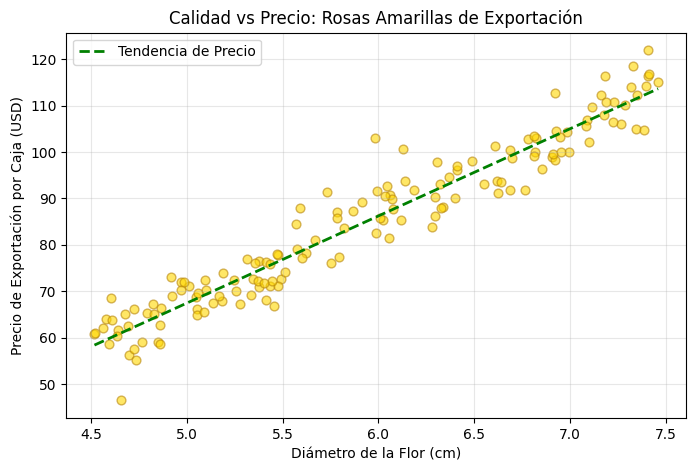

La línea verde confirma la tendencia: a mayor diámetro de la flor, mayor es el precio en el mercado internacional.


In [7]:
## 1.3 - Visualización de la tendencia comercial
plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.6, color='gold', edgecolor='darkgoldenrod', s=40)

# Línea de tendencia comercial (valoración ideal)
m, b = np.polyfit(X.flatten(), y.flatten(), 1)
x_linea = np.linspace(X.min(), X.max(), 100)
plt.plot(x_linea, m * x_linea + b, color='green', linewidth=2,
         linestyle='--', label='Tendencia de Precio')

plt.xlabel('Diámetro de la Flor (cm)')
plt.ylabel('Precio de Exportación por Caja (USD)')
plt.title('Calidad vs Precio: Rosas Amarillas de Exportación')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("La línea verde confirma la tendencia: a mayor diámetro de la flor, mayor es el precio en el mercado internacional.")

In [8]:
## 1.4 - División y normalización de los datos
# Separamos en entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalizamos para que la red neuronal aprenda de una forma más eficiente
# Esto lleva todos los valores a media 0 y desviación estándar 1
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (120, 1)
Datos de prueba: (30, 1)
